# Predicción de visibilidad atmosférica a partir de PM10 - Piura, Perú

Objetivo: predecir la visibilidad atmosférica (km) a partir de la concentración
de PM10 medida en 3 estaciones de monitoreo (26 de Octubre, UDEP, Piura).

Modelos comparados:
* Regresión Lineal Múltiple
* KNN Regressor
* Random Forest
* Gradient Boosting
* Support Vector Regression (SVR)

# Librerias

In [ ]:
# Librerías estándar de manipulación y visualización
import warnings
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42  # semilla fija

In [48]:
# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Selección de datos, validación y ajuste de hiperparámetros
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Regresión
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Otro
from sklearn.model_selection import KFold

## 1. Carga de datos

In [ ]:
url_pm10 = 'https://raw.githubusercontent.com/JoaoSanchez14/Prediccion-visibilidad-pm10-peru/main/raw-pm10-gm.csv'
url_vis = 'https://raw.githubusercontent.com/JoaoSanchez14/Prediccion-visibilidad-pm10-peru/main/visual-range-km.csv'

df_pm10_raw = pd.read_csv(url_pm10)
df_vis_raw = pd.read_csv(url_vis)

print("PM10:", df_pm10_raw.shape, "- Visibilidad:", df_vis_raw.shape)
df_pm10_raw.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PM10: (366, 8) - Visibilidad: (366, 8)


,DateTime,Average,GEOHealth_PIU_26Oct A,GEOHealth_PIU_26Oct B,GEOHealth_PIU_UDEP A,GEOHealth_PIU_UDEP B,GEOHealth_PIU_Piura A,GEOHealth_PIU_Piura B
0,2024-11-24 00:00:00,14.9,17.2,18.4,15.5,16.2,NaN,NaN
1,2024-11-25 00:00:00,NaN,17.3,18.5,16.0,16.3,NaN,NaN
2,2024-11-26 00:00:00,NaN,15.5,16.5,14.6,15.1,NaN,NaN
3,2024-11-27 00:00:00,NaN,14.2,15.1,13.6,13.9,NaN,NaN
4,2024-11-28 00:00:00,NaN,16.4,17.5,14.8,15.1,NaN,NaN


In [50]:
df_vis_raw.head()

,DateTime,Average,GEOHealth_PIU_26Oct A,GEOHealth_PIU_26Oct B,GEOHealth_PIU_UDEP A,GEOHealth_PIU_UDEP B,GEOHealth_PIU_Piura A,GEOHealth_PIU_Piura B
0,2024-11-24 00:00:00,98.1,86.2,79.7,96.7,93.0,NaN,NaN
1,2024-11-25 00:00:00,NaN,85.4,79.1,95.2,92.1,NaN,NaN
2,2024-11-26 00:00:00,NaN,92.4,85.9,101.4,97.8,NaN,NaN
3,2024-11-27 00:00:00,NaN,97.0,90.5,106.3,102.6,NaN,NaN
4,2024-11-28 00:00:00,NaN,88.2,81.9,99.8,96.2,NaN,NaN


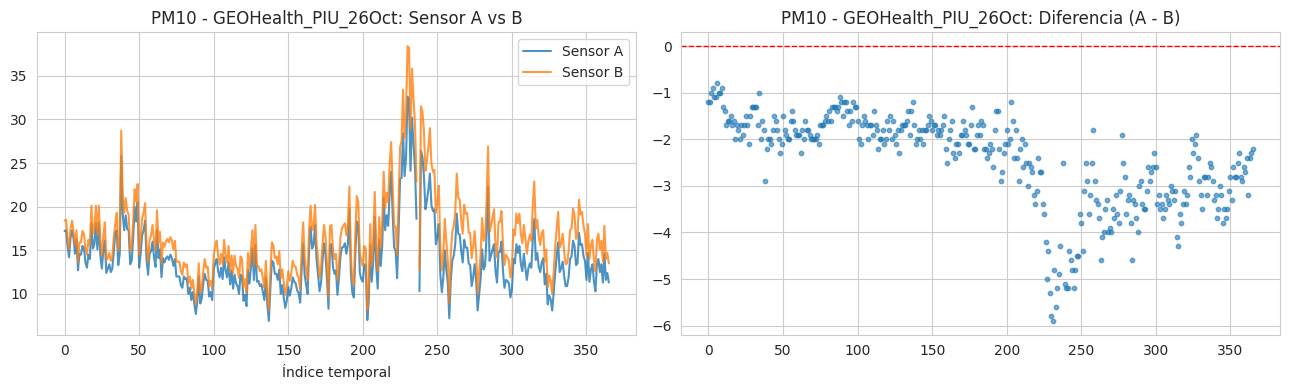

--- PM10 - GEOHealth_PIU_26Oct ---
Valores Nulos -> Sensor A: 1 | Sensor B: 1


,Sensor A,Sensor B,Diferencia (A-B)
mean,14.095,16.537,-2.442
std,3.901,4.613,1.000
min,6.900,8.100,-5.900
max,32.600,38.400,-0.800


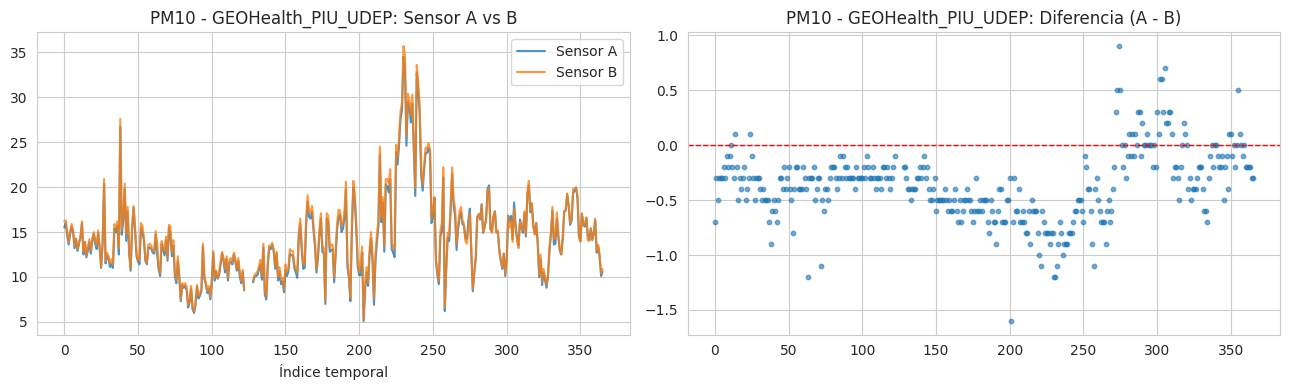

--- PM10 - GEOHealth_PIU_UDEP ---
Valores Nulos -> Sensor A: 5 | Sensor B: 5


,Sensor A,Sensor B,Diferencia (A-B)
mean,14.246,14.611,-0.364
std,4.667,4.771,0.320
min,5.100,5.400,-1.600
max,34.500,35.700,0.900


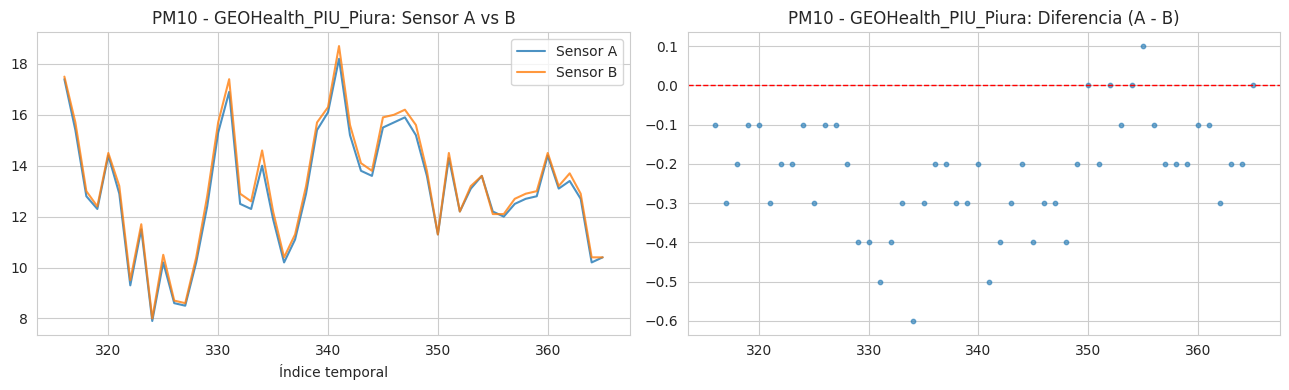

--- PM10 - GEOHealth_PIU_Piura ---
Valores Nulos -> Sensor A: 316 | Sensor B: 316


,Sensor A,Sensor B,Diferencia (A-B)
mean,13.000,13.224,-0.224
std,2.303,2.372,0.144
min,7.900,8.000,-0.600
max,18.200,18.700,0.100


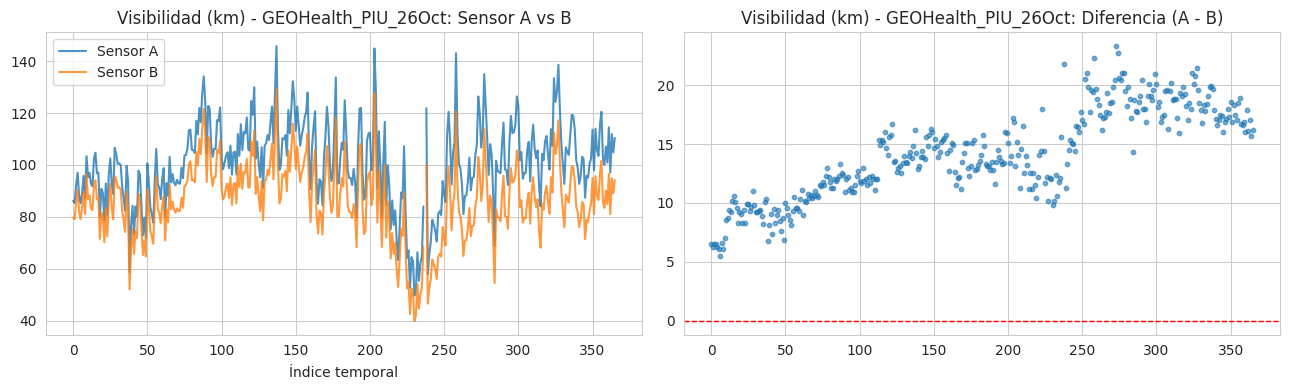

--- Visibilidad (km) - GEOHealth_PIU_26Oct ---
Valores Nulos -> Sensor A: 1 | Sensor B: 1


,Sensor A,Sensor B,Diferencia (A-B)
mean,100.603,86.423,14.180
std,16.093,14.577,3.784
min,49.700,39.900,5.500
max,145.800,129.600,23.300


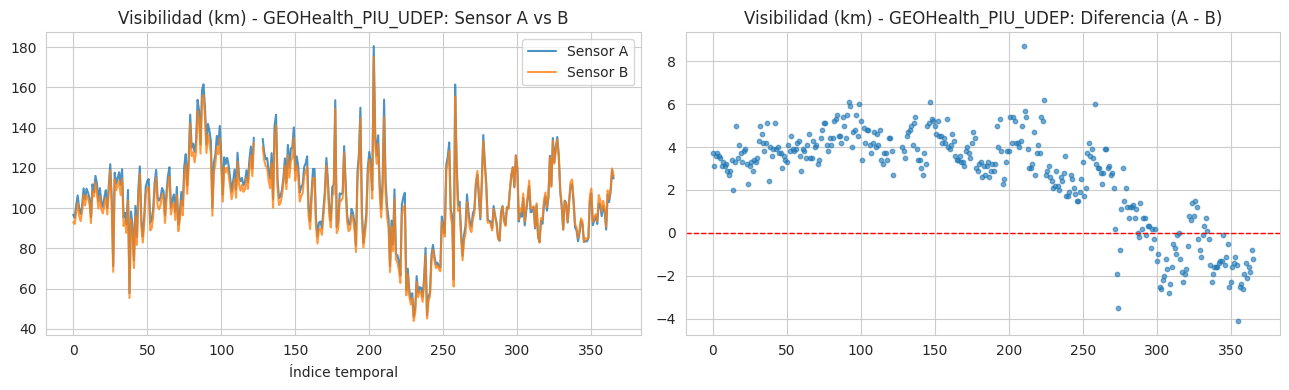

--- Visibilidad (km) - GEOHealth_PIU_UDEP ---
Valores Nulos -> Sensor A: 5 | Sensor B: 5


,Sensor A,Sensor B,Diferencia (A-B)
mean,105.394,102.761,2.633
std,20.430,19.718,2.277
min,46.000,43.900,-4.100
max,180.500,175.100,8.700


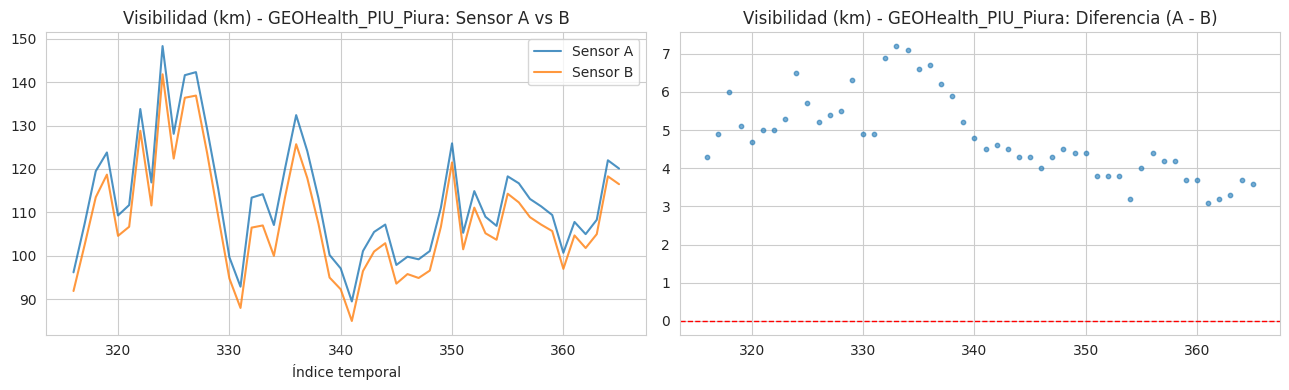

--- Visibilidad (km) - GEOHealth_PIU_Piura ---
Valores Nulos -> Sensor A: 316 | Sensor B: 316


,Sensor A,Sensor B,Diferencia (A-B)
mean,112.904,108.088,4.816
std,12.933,12.543,1.075
min,89.500,85.000,3.100
max,148.300,141.800,7.200


In [51]:
def resumen_comparacion_ab(df, col_a, col_b, titulo):
    """Compara dos sensores (A/B) de una misma estación: serie temporal,
    estadísticas descriptivas en formato tabla y diferencia entre ambos
    """
    diff = df[col_a] - df[col_b]

    # Graficación
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(df[col_a].values, label="Sensor A", alpha=0.8)
    axes[0].plot(df[col_b].values, label="Sensor B", alpha=0.8)
    axes[0].set_title(f"{titulo}: Sensor A vs B")
    axes[0].set_xlabel("Índice temporal")
    axes[0].legend()

    axes[1].scatter(diff.index, diff, s=10, alpha=0.6)
    axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[1].set_title(f"{titulo}: Diferencia (A - B)")
    plt.tight_layout()
    plt.show()

    # Tabla de estadísticas
    tabla_stats = pd.DataFrame({
        'Sensor A': df[col_a].describe(),
        'Sensor B': df[col_b].describe(),
        'Diferencia (A-B)': diff.describe()
    })

    tabla_stats = tabla_stats.loc[['mean', 'std', 'min', 'max']]

    print(f"--- {titulo} ---")
    print(f"Valores Nulos -> Sensor A: {df[col_a].isna().sum()} | Sensor B: {df[col_b].isna().sum()}")
    display(tabla_stats.round(3))

# Estaciones a comparar (sensor A vs sensor B)
estaciones = ["GEOHealth_PIU_26Oct",
              "GEOHealth_PIU_UDEP",
              "GEOHealth_PIU_Piura"]

# Para PM10
for est in estaciones:
    resumen_comparacion_ab(df_pm10_raw, f"{est} A", f"{est} B", f"PM10 - {est}")

# Para Visibilidad
for est in estaciones:
    resumen_comparacion_ab(df_vis_raw, f"{est} A", f"{est} B", f"Visibilidad (km) - {est}")

Hallazgo clave:

1. Material particulado (PM10): Tras evaluar las métricas descriptivas, se observó que el grupo de Sensores A presentó una varianza menor en comparación con los Sensores B en las tres estaciones evaluadas. Los sensores B evidenciaron un comportamiento más errático, con fluctuaciones mayores a las de A.

Decisión: Se seleccionó los sensores de A como la fuente oficial para el análisis de PM10 y se descartaron por completo los 3 sensores B.

2. Visibilidad (km): Para la variable de visibilidad meteorológica, el comportamiento de los instrumentos se invirtió: los sensores B demostraron una varianza menor, manteniendo lecturas consistentes con los límites físicos del entorno. Por el contrario, los sensores A registraron una dispersión más alta en la señal, probablemente asociados a una descalibración óptica o susceptibilidad a la humedad relativa.

Decisión: Se seleccionó los sensores de B como la fuente oficial para el análisis de Visibilidad y se descartaron por completo los 3 sensores A.

## 2. Preprocesamiento

### 2.1 Selección de columnas y formato largo (long format)

In [52]:
def preparar_df(df_raw, sufijo_valido):
    """Se queda solo con el sensor sufijo_valido ('A' o 'B') de cada estación
    y renombra a S1, S2, S3"""
    columnas_mantener = [f"{est} {sufijo_valido}" for est in estaciones]
    renombrar = {f"{est} {sufijo_valido}": f"S{i+1}" for i, est in enumerate(estaciones)}
    return df_raw[["DateTime"] + columnas_mantener].rename(columns=renombrar)

df_pm10 = preparar_df(df_pm10_raw, "A")
df_vis = preparar_df(df_vis_raw, "B")


def a_formato_largo(df, nombre_variable):
    """Convierte de formato ancho (una columna por estación) a formato largo
    (una fila por combinación fecha-estación), necesario para entrenar un solo
    modelo que use 'station_id' como variable categórica
    """
    return df.melt(
        id_vars="DateTime",
        value_vars=["S1", "S2", "S3"],
        var_name="station_id",
        value_name=nombre_variable,
    )

df_pm10_long = a_formato_largo(df_pm10, "pm10")
df_vis_long = a_formato_largo(df_vis, "visibility_km")

# Unimos ambas variables por fecha y estación
df = reduce(
    lambda izq, der: izq.merge(der, on=["DateTime", "station_id"], how="outer"),
    [df_pm10_long, df_vis_long],
)

# Formato de fecha explícito (evita ambigüedad día/mes y warnings de pandas)
df["DateTime"] = pd.to_datetime(df["DateTime"], format="%Y-%m-%d %H:%M:%S")
df = df.sort_values(["station_id", "DateTime"]).reset_index(drop=True)
df.head()

,DateTime,station_id,pm10,visibility_km
0,2024-11-24,S1,17.2,79.7
1,2024-11-25,S1,17.3,79.1
2,2024-11-26,S1,15.5,85.9
3,2024-11-27,S1,14.2,90.5
4,2024-11-28,S1,16.4,81.9


### 2.2 Manejo de valores nulos

In [53]:
print("Nulos antes de interpolar:")
print(df.isna().sum())

Nulos antes de interpolar:
DateTime           0
station_id         0
pm10             322
visibility_km    322
dtype: int64


In [54]:
def interpolar_pm10_por_estacion(df_estacion):
    """Interpola PM10 usando la fecha como eje (method='time') para UNA
    estación, y rellena los extremos (ffill/bfill) si la interpolación no
    alcanza a cubrirlos
    """
    df_estacion = df_estacion.sort_values("DateTime").drop_duplicates(subset="DateTime")
    df_estacion = df_estacion.set_index("DateTime")
    df_estacion["pm10"] = df_estacion["pm10"].interpolate(method="time").ffill().bfill()
    return df_estacion.reset_index()

df = pd.concat(
    [interpolar_pm10_por_estacion(grupo) for _, grupo in df.groupby("station_id")],
    ignore_index=True,
)

df = df.dropna(subset=["pm10", "visibility_km"]).reset_index(drop=True)

print("Nulos después de limpiar:")
print(df.isna().sum())
print(f"\nFilas finales utilizables: {len(df)}")

Nulos después de limpiar:
DateTime         0
station_id       0
pm10             0
visibility_km    0
dtype: int64

Filas finales utilizables: 776


### 2.3 Detección y tratamiento de outliers (PM10)

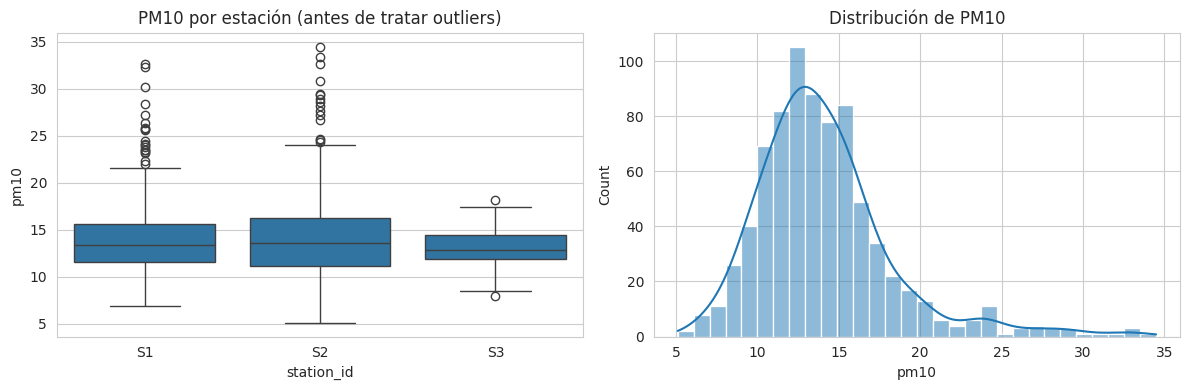

Outliers detectados (IQR, 1.5x) en todas las estaciones: 36


In [55]:
def limites_iqr(serie, factor=1.5):
    """Calcula los límites inferior/superior según el método IQR"""
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="station_id", y="pm10", ax=ax[0])
ax[0].set_title("PM10 por estación (antes de tratar outliers)")
sns.histplot(df["pm10"], bins=30, kde=True, ax=ax[1])
ax[1].set_title("Distribución de PM10")
plt.tight_layout()
plt.show()

n_outliers = 0
for estacion, grupo in df.groupby("station_id"):
    inf, sup = limites_iqr(grupo["pm10"])
    n_outliers += ((grupo["pm10"] < inf) | (grupo["pm10"] > sup)).sum()
print(f"Outliers detectados (IQR, 1.5x) en todas las estaciones: {n_outliers}")

In [56]:
def calcular_limites_iqr_por_grupo(df, columna, grupo_col, factor=1.5):
    """Calcula los límites IQR por estación solo con los datos recibidos
    (debe llamarse con el train, nunca con el dataset completo, para evitar
    fuga de información del test hacia el entrenamiento)
    """
    return {
        estacion: limites_iqr(grupo[columna], factor)
        for estacion, grupo in df.groupby(grupo_col)
    }

def aplicar_capping(df, columna, grupo_col, limites):
    """Aplica límites ya calculados (de train) a cualquier dataset (train o test)"""
    df = df.copy()
    for estacion, idx in df.groupby(grupo_col).groups.items():
        inf, sup = limites[estacion]
        df.loc[idx, columna] = df.loc[idx, columna].clip(lower=inf, upper=sup)
    return df

### 2.4 División Train/Test

In [57]:
def split_temporal_por_estacion(df, test_size=0.2):
    """Para cada estación, separa el último test_size de las fechas como test.
    Evita que el modelo 'vea' información futura cercana al test durante el
    entrenamiento
    """
    partes_train, partes_test = [], []
    for _, grupo in df.groupby("station_id"):
        grupo = grupo.sort_values("DateTime")
        corte = int(len(grupo) * (1 - test_size))
        partes_train.append(grupo.iloc[:corte])
        partes_test.append(grupo.iloc[corte:])
    return pd.concat(partes_train).reset_index(drop=True), pd.concat(partes_test).reset_index(drop=True)

df_train, df_test = split_temporal_por_estacion(df, test_size=0.2)

print(f"Train: {len(df_train)} filas | Test: {len(df_test)} filas")

Train: 620 filas | Test: 156 filas


### 2.4.1 Aplicación del capping (ajustado solo con train)

Los límites IQR se calculan únicamente con df_train y se aplican igual a df_train y df_test, para que el set de test no influya en los límites de tratamiento de outliers

In [58]:
limites_pm10 = calcular_limites_iqr_por_grupo(df_train, "pm10", "station_id")

df_train = aplicar_capping(df_train, "pm10", "station_id", limites_pm10)
df_test = aplicar_capping(df_test, "pm10", "station_id", limites_pm10)

FEATURES = ["pm10", "station_id"]
TARGET = "visibility_km"

X_train, y_train = df_train[FEATURES], df_train[TARGET]
X_test, y_test = df_test[FEATURES], df_test[TARGET]

### 2.5 Escalado de variables (pipeline de preprocesamiento)

In [59]:
# station_id es categórica (3 estaciones) -> One-Hot Encoding
# pm10 es numérica -> StandardScaler (media 0, desviación 1)
preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["pm10"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["station_id"]),
    ]
)

## 3. Modelado

Se entrenan 5 modelos dentro de un `Pipeline` (preprocesador + estimador), y se
optimizan sus hiperparámetros principales con GridSearchCV usando validación
cruzada (cv = 5). Esto evita fijar hiperparámetros "a ojo" y reduce el riesgo de
sobreajuste al elegirlos con datos que el modelo no ve en cada fold

In [60]:
CV_FOLDS = KFold(n_splits=5,
                 shuffle=True,
                 random_state = RANDOM_STATE)
SCORING = "neg_mean_squared_error"  # GridSearchCV minimiza el error (MSE)

### 3.1 Regresión Lineal Múltiple (RLM)

In [61]:
pipe_lr = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", LinearRegression()),
])

# La regresión lineal no tiene hiperparámetros relevantes que ajustar aquí,
# por lo que se entrena directamente (sirve como modelo base)
pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['pm10']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['station_id'])])),
                ('modelo', LinearRegression())])

### 3.2 KNN Regressor

In [62]:
pipe_knn = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", KNeighborsRegressor()),
])

param_grid_knn = {
    "modelo__n_neighbors": list(range(1, 31)),
    "modelo__weights": ["uniform", "distance"],
    "modelo__metric": ["euclidean", "manhattan", "chebyshev"],
}

grid_knn = GridSearchCV(
    pipe_knn,
    param_grid_knn,
    cv= CV_FOLDS,
    scoring= SCORING,
    n_jobs =-1
)
grid_knn.fit(X_train, y_train)

print("Mejores hiperparámetros KNN:", grid_knn.best_params_)

Mejores hiperparámetros KNN: {'modelo__metric': 'manhattan', 'modelo__n_neighbors': 7, 'modelo__weights': 'uniform'}


### 3.3 Random Forest Regressor

In [63]:
pipe_rf = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", RandomForestRegressor(random_state= RANDOM_STATE)),
])

param_grid_rf = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [None, 5, 10, 15],
    "modelo__min_samples_leaf": [1, 2, 5],
}

grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv= CV_FOLDS,
    scoring= SCORING,
    n_jobs= -1
)
grid_rf.fit(X_train, y_train)

print("Mejores hiperparámetros Random Forest:", grid_rf.best_params_)

Mejores hiperparámetros Random Forest: {'modelo__max_depth': 5, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 100}


### 3.4 Gradient Boosting Regressor

In [64]:
pipe_gb = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", GradientBoostingRegressor(random_state= RANDOM_STATE)),
])

param_grid_gb = {
    "modelo__n_estimators": [100, 200],
    "modelo__learning_rate": [0.01, 0.05, 0.1],
    "modelo__max_depth": [2, 3, 4],
}

grid_gb = GridSearchCV(
    pipe_gb,
    param_grid_gb,
    cv= CV_FOLDS,
    scoring= SCORING,
    n_jobs= -1
)
grid_gb.fit(X_train, y_train)

print("Mejores hiperparámetros Gradient Boosting:", grid_gb.best_params_)

Mejores hiperparámetros Gradient Boosting: {'modelo__learning_rate': 0.05, 'modelo__max_depth': 2, 'modelo__n_estimators': 200}


### 3.5 Support Vector Regression (SVR)

In [65]:
pipe_svr = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", SVR()),
])

param_grid_svr = {
    "modelo__kernel": ["rbf", "linear"],
    "modelo__C": [0.1, 1, 10, 100],
    "modelo__gamma": ["scale", "auto"],
}

grid_svr = GridSearchCV(
    pipe_svr,
    param_grid_svr,
    cv= CV_FOLDS,
    scoring= SCORING,
    n_jobs= -1
)
grid_svr.fit(X_train, y_train)

print("Mejores hiperparámetros SVR:", grid_svr.best_params_)

Mejores hiperparámetros SVR: {'modelo__C': 100, 'modelo__gamma': 'auto', 'modelo__kernel': 'rbf'}


## 4. Evaluación

### 4.1 Métricas en el set de prueba (Test)

In [66]:
modelos_finales = {
    "Regresión Lineal": pipe_lr,
    "KNN": grid_knn.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "Gradient Boosting": grid_gb.best_estimator_,
    "SVR": grid_svr.best_estimator_,
}


def evaluar_modelo(nombre, modelo, X_test, y_test):
    """Calcula RMSE, MAE y R2 para un modelo ya entrenado"""
    y_pred = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return {"Modelo": nombre, "RMSE": rmse, "MAE": mae, "R2": r2}


resultados = pd.DataFrame(
    [evaluar_modelo(nombre, m, X_test, y_test) for nombre, m in modelos_finales.items()]
).sort_values("RMSE").reset_index(drop=True)

resultados

,Modelo,RMSE,MAE,R2
0,Random Forest,4.477774,3.455939,0.882453
1,Regresión Lineal,4.529707,3.773474,0.879711
2,KNN,4.668798,3.655678,0.872210
3,SVR,4.672563,3.584933,0.872004
4,Gradient Boosting,4.763003,3.706709,0.867001


### 4.2 Validación cruzada (detección de sobreajuste)

In [67]:
filas_cv = []
for nombre, modelo in modelos_finales.items():
    scores_rmse = -cross_val_score(
        modelo, X_train, y_train, cv= CV_FOLDS, scoring= SCORING, n_jobs= -1
    )
    scores_rmse = np.sqrt(scores_rmse)
    filas_cv.append({
        "Modelo": nombre,
        "RMSE_CV_promedio": scores_rmse.mean(),
        "RMSE_CV_std": scores_rmse.std(),
    })

resultados_cv = pd.DataFrame(filas_cv).sort_values("RMSE_CV_promedio").reset_index(drop=True)
resultados_cv

,Modelo,RMSE_CV_promedio,RMSE_CV_std
0,SVR,3.662032,0.454658
1,Gradient Boosting,3.787913,0.407134
2,Random Forest,3.894582,0.359300
3,KNN,4.110387,0.372264
4,Regresión Lineal,4.635046,0.265841


Cómo interpretar esta tabla: si el `RMSE` de test (sección 4.1) es muy
inferior al `RMSE_CV_promedio`, es señal de que el split train/test fue
"afortunado" y el modelo podría no generalizar igual con otros datos. Una
`RMSE_CV_std` alta indica que el desempeño varía mucho entre folds (modelo
inestable); lo ideal es un promedio bajo y una desviación baja a la vez

### 4.3 Visualización: Real vs. Predicho (todos los modelos)

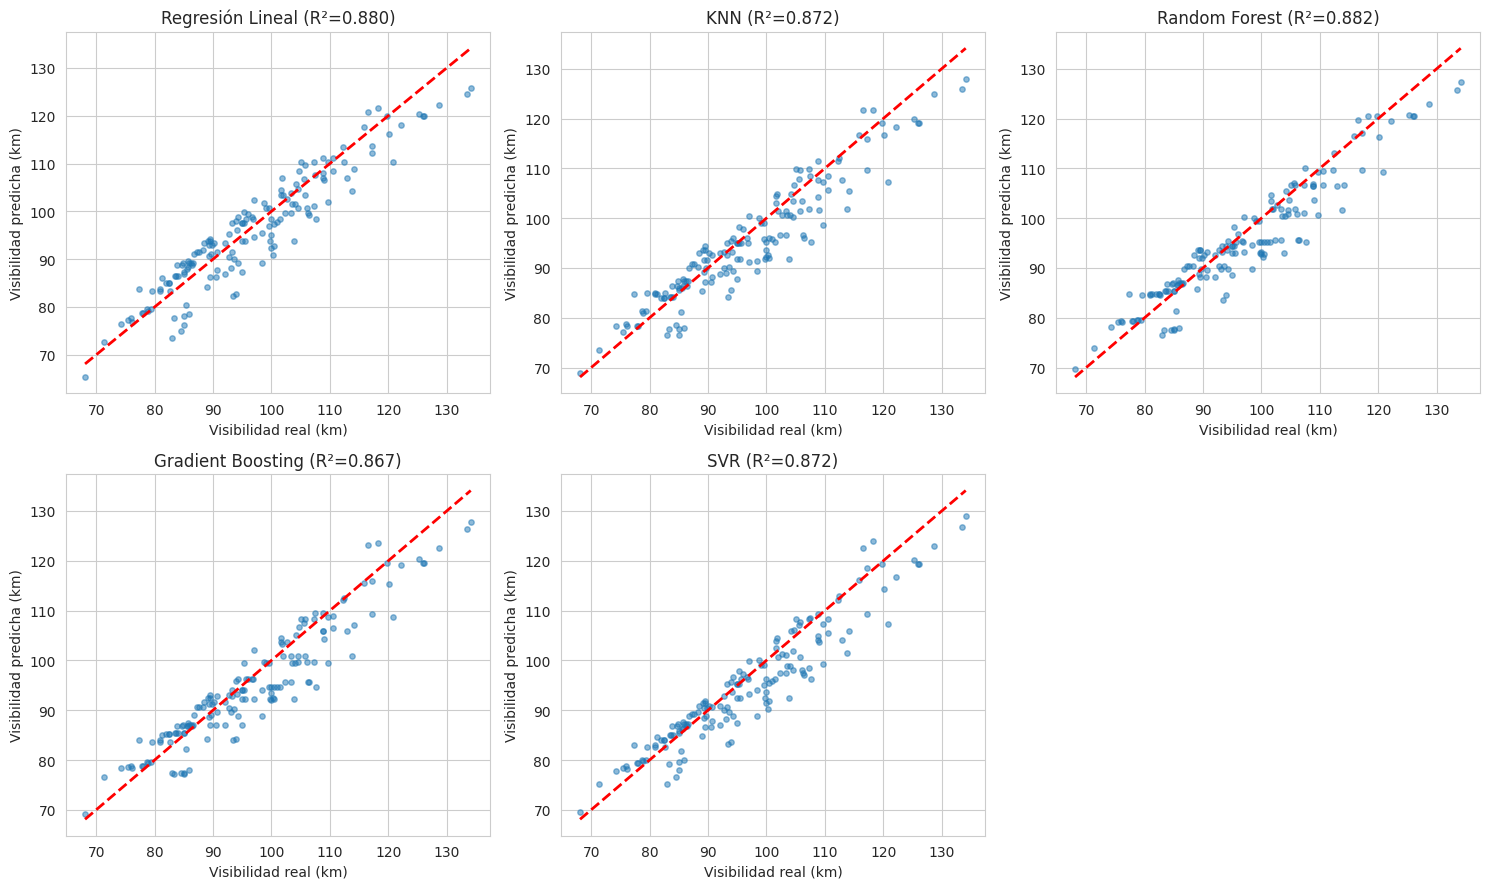

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(modelos_finales.items()):
    y_pred = modelo.predict(X_test)
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.5, s=15)
    lim_min, lim_max = y_test.min(), y_test.max()
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth = 2)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f"{nombre} (R²={r2:.3f})")
    ax.set_xlabel("Visibilidad real (km)")
    ax.set_ylabel("Visibilidad predicha (km)")

axes[-1].axis("off")  # último subplot vacío (5 modelos en grilla 2x3)
plt.tight_layout()
plt.show()

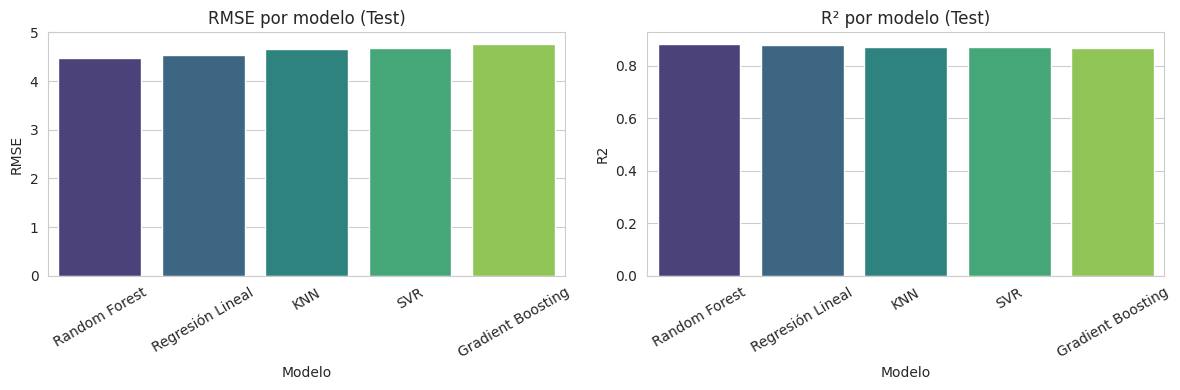

Mejor modelo según RMSE de test: Random Forest


In [69]:
# Gráfico de barras comparativo final
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data = resultados, x="Modelo", y="RMSE", ax=ax[0], palette="viridis")
ax[0].set_title("RMSE por modelo (Test)")
ax[0].tick_params(axis="x", rotation=30)

sns.barplot(data=resultados, x="Modelo", y="R2", ax=ax[1], palette="viridis")
ax[1].set_title("R² por modelo (Test)")
ax[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print(f"Mejor modelo según RMSE de test: {resultados.iloc[0]['Modelo']}")

## Conclusiones

1) Sobre los datos

El dataset combinado quedó en 776 filas utilizables (de un total mucho mayor). La estación Piura concentra 316 de 366 días sin dato tanto en PM10 como en visibilidad, es decir, casi el 86% de esa estación está vacía, así que en la práctica el modelo aprende mayormente de las estaciones 26 de Octubre y UDEP, y la estación Piura aporta muy poca información real. Esto es importante: cualquier conclusión sobre "qué tan bien generaliza el modelo a las 3 estaciones" debe matizarse, porque una de las tres casi no tiene datos.

2) Sobre la relación PM10 - visibilidad

El R² de todos los modelos está entre 0.882 y 0.867 en el set de test, lo cual indica que el PM10 por sí solo explica la gran mayoría de la variabilidad en visibilidad. Esto tiene sentido físico (más material particulado en el aire dispersa la luz y reduce el rango visual), y confirma que la variable elegida como predictor principal es adecuada, no haría falta mucho más para tener un buen modelo.

3) Sobre el mejor modelo

  3.1) El ganador por precisión: SVR

Es el modelo que mejor minimiza los errores de predicción. Al obtener el RMSE promedio más bajo (3.662) en la validación cruzada, demuestra tener la mayor capacidad general para acercarse a los valores reales. Si el objetivo técnico principal es tener el menor margen de error posible, el SVR es la elección correcta.

  3.2) El mejor equilibrio (Precisión vs. Estabilidad): Random Forest

Aunque el SVR gana en el error promedio, su desviación estándar (0.455) indica que su rendimiento fluctúa más dependiendo de los datos con los que se entrene.

Random Forest (RMSE: 3.895, Std: 0.359) presenta un error marginalmente superior, pero es el más estable y consistente de los modelos líderes. Si necesitas un algoritmo que se comporte de forma predecible en un entorno real con datos nuevos, y que además te permita interpretar fácilmente qué variables tienen mayor peso en la predicción (feature importance), esta es tu mejor opción.